In [1]:
import earthaccess
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
# Login to earth access
earthaccess.login()

In [ ]:
# Explore metadata of the SMAP-S1 dataset
# datasets = earthaccess.search_datasets(
#     short_name = 'SPL2SMAP_S',
#     version = '003'
# )
# print(len(datasets))
# print(datasets[0].summary())

In [ ]:
# Explore available images in the SMAP-S1 dataset
# data = earthaccess.search_data(
#     short_name = 'SPL2SMAP_S',
#     version = '003',
#     temporal = ('2015-01-01', '2026-12-31'),
#     point = (-68.86417, -20.26568)
# )
# print(len(data))
# print(data[0])

### Soil moisture retrieval

In [ ]:
def process_single_granule(granule_metadata, file_handle, target_lat, target_lon, max_dist_deg=0.05):
    """
    Parses coordinates and extracts soil moisture for a single granule.
    Executed concurrently across threads.
    """
    granule_name = granule_metadata['umm']['DataGranule']['Identifiers'][0]['Identifier']

    try:
        # Each thread safely reads from its pre-opened file handle
        with xr.open_dataset(
            file_handle,
            group='Soil_Moisture_Retrieval_Data_1km',
            engine='h5netcdf',
            phony_dims='sort'
        ) as ds:
            # Dynamic coordinate lookup per swath/orbit
            lats = ds['latitude_1km'].values
            lons = ds['longitude_1km'].values

            dist_sq = (lats - target_lat)**2 + (lons - target_lon)**2
            min_idx = np.unravel_index(np.argmin(dist_sq), dist_sq.shape)

            # Spatial distance validation (approx. 5 km limit)
            if np.sqrt(dist_sq[min_idx]) > max_dist_deg:
                return None

            val = float(ds['soil_moisture_1km'].values[min_idx])

            if val != -9999.0 and not np.isnan(val):
                date_str = granule_name.split('_')[6]
                timestamp = pd.to_datetime(date_str, format='%Y%m%dT%H%M%S')
                return {'date': timestamp, 'soil_moisture': val}

    except Exception:
        # Catch individual read or network transfer errors
        return None

    return None

def process_multi_year_series(start_date, end_date, target_lon, target_lat, max_workers=8):
    """
    Orchestrates monthly batch searches and concurrent file processing.
    """

    batch_starts = pd.date_range(start=start_date, end=end_date, freq='MS')
    batch_ends = pd.date_range(start=start_date, end=end_date, freq='ME')

    all_records = []

    for b_start, b_end in zip(batch_starts, batch_ends):
        s_str = b_start.strftime('%Y-%m-%d')
        e_str = b_end.strftime('%Y-%m-%d')

        granules = earthaccess.search_data(
            short_name='SPL2SMAP_S',
            version='003',
            temporal=(s_str, e_str),
            point=(target_lon, target_lat)
        )

        if not granules:
            continue

        # Open handles sequentially/safely in the main thread
        file_handles = earthaccess.open(granules)

        # Distribute extraction across worker threads
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [
                executor.submit(
                    process_single_granule, 
                    g_meta, 
                    f_handle, 
                    target_lat, 
                    target_lon
                )
                for g_meta, f_handle in zip(granules, file_handles)
            ]
            
            for future in futures:
                result = future.result()
                if result:
                    all_records.append(result)

    if not all_records:
        return pd.DataFrame(columns=['date', 'soil_moisture'])

    df = pd.DataFrame(all_records)
    return df.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)

def plot_multi_year_series(dataframe):
    """
    Plots the final soil moisture time series.
    """
    if dataframe.empty:
        print("No valid data points found.")
        return

    plt.figure(figsize=(12, 5))
    plt.plot(dataframe['date'], dataframe['soil_moisture'], marker='o', linestyle='', markersize=4, color='b')
    plt.title('SMAP/Sentinel-1 Soil Moisture (1 km)')
    plt.xlabel('Date')
    plt.ylabel('Soil Moisture (cm³/cm³)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Config
target_longitude = -68.86417
target_latitude = -20.26568
start_date = '2024-01-01'
end_date = '2026-08-31'

In [ ]:
# Execution
sm = process_multi_year_series(
    start_date=start_date,
    end_date=end_date,
    target_lon=target_longitude,
    target_lat=target_latitude,
    max_workers=16
)

/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 14/14 [00:00<00:00, 2310.64it/s]
PROCESSING TASKS | : 100%|██████████| 14/14 [00:05<00:00,  2.41it/s]
COLLECTING RESULTS | : 100%|██████████| 14/14 [00:00<00:00, 212754.55it/s]
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCo

In [ ]:
sm_df = sm.copy()

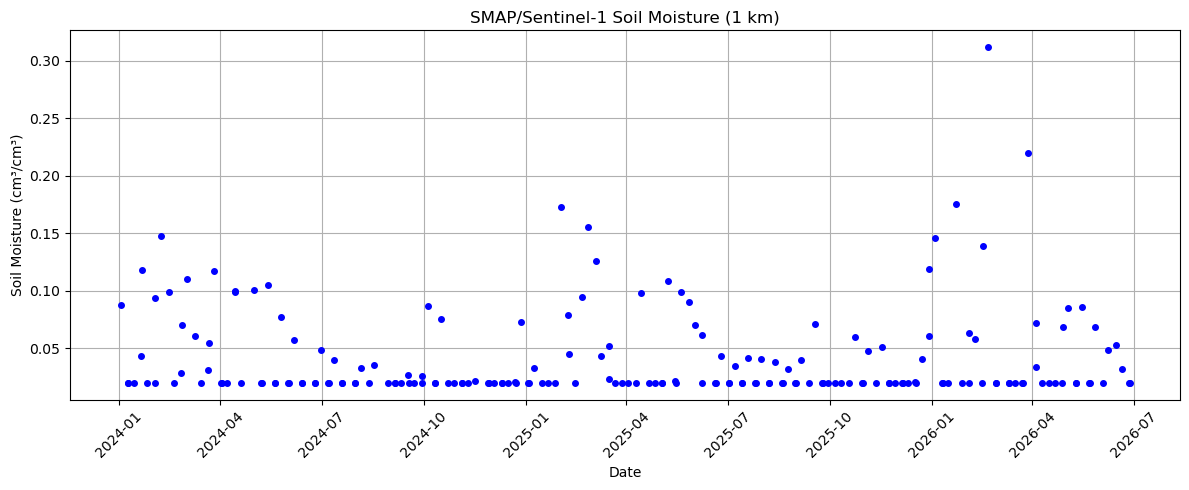

In [ ]:
# Plotting
plot_multi_year_series(sm_df)

In [ ]:
# Format date and set as index
sm_df['date']= sm_df['date'].dt.normalize()
sm_df = sm_df.set_index('date')

### Comparación con datos in-situ

In [1]:
from v2_data_preparation import process_insitu
from scipy.stats import zscore

In [2]:
insitu = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    start_date='2024-07-25',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m', 'TEROS12-05cm_water-content_m3m3', 'TEROS12-15cm_water-content_m3m3', 'ATMOS41_precipitation_mm'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)

In [ ]:
insitu

In [4]:
# Separar df en dias de pp y no pp
n = 1           # number of days to consider after a precipitation event
min_pp = 0.0    # minimum amount of rain to consider as an event

# Filter non significant rain events
rained = insitu['ATMOS41_precipitation_mm'] > min_pp

# Configure a filtering mask using rolling and max
pp_mask = (
    rained.rolling(f'{n + 1}D').max().astype(bool)
)

# Divide dataframe based on mask
pp_df = insitu[pp_mask]
no_pp_df = insitu[~pp_mask]

In [5]:
pp_df

,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm
2024-10-05,-0.215,0.201,0.372,1.004
2024-10-06,-0.212,0.202,0.371,0.000
2024-11-22,-0.546,0.152,0.291,0.749
2024-11-23,-0.530,0.152,0.291,1.071
2024-11-24,-0.516,0.152,0.291,1.514
...,...,...,...,...
2026-04-17,-0.600,NaN,0.276,0.017
2026-04-18,-0.602,NaN,0.276,0.000
2026-04-21,-0.598,NaN,0.276,0.034
2026-04-22,-0.595,NaN,0.277,0.068


In [ ]:
# Separar df en dias donde nivel freatico es somero
level_thresh = -0.3
shallow = no_pp_df['SDH1PS01_gw-depth_m'] >= level_thresh
shallow_df = no_pp_df[shallow]

In [ ]:
insitu_z = insitu.apply(zscore, nan_policy='omit')
sm_z = sm_df.apply(zscore, nan_policy='omit')

#### Correlations

In [ ]:
def prepare_and_correlate(df1, df2, df1_vars = None, df2_vars = None, corr_method='pearson', min_obs = 30):
    """
    Filters data by selected variables, merges on datetime index, and calculates correlation.
    """
    # filter columns based on user selection
    if df1_vars:
        df1 = df1[df1_vars]
    if df2_vars:
        df2 = df2[df2_vars]

    # merge both datasets using their datetime index
    merged_data = pd.merge(
        df1, 
        df2, 
        left_index=True, 
        right_index=True, 
        how='inner'
    )

    # filter columns without minimum number of observations
    merged_data = merged_data.dropna(axis=1, thresh=min_obs)

    # calculate the correlation matrix
    correlation_matrix = merged_data.corr(
        method=corr_method,
        #min_periods=min_obs
    )
    
    return correlation_matrix, merged_data

Correlaciones en periodo completo

In [ ]:
corr_matrix, merged = prepare_and_correlate(sm_df, insitu, corr_method='pearson', min_obs=30)
corr_matrix

,soil_moisture,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm
soil_moisture,1.000000,-0.077017,-0.100326,-0.156025,0.313445
SDH1PS01_gw-depth_m,-0.077017,1.000000,0.829673,0.872993,-0.050013
TEROS12-05cm_water-content_m3m3,-0.100326,0.829673,1.000000,0.873877,-0.096662
TEROS12-15cm_water-content_m3m3,-0.156025,0.872993,0.873877,1.000000,-0.144608
ATMOS41_precipitation_mm,0.313445,-0.050013,-0.096662,-0.144608,1.000000


Correlaciones en periodo de precipitaciones

In [ ]:
corr_matrix_pp, merged_pp = prepare_and_correlate(sm_df, pp_df, corr_method='pearson', min_obs=10)
corr_matrix_pp

,soil_moisture,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm
soil_moisture,1.000000,0.306712,-0.191104,0.170739,0.278849
SDH1PS01_gw-depth_m,0.306712,1.000000,-0.394426,0.405937,0.162246
TEROS12-05cm_water-content_m3m3,-0.191104,-0.394426,1.000000,-0.385695,-0.472923
TEROS12-15cm_water-content_m3m3,0.170739,0.405937,-0.385695,1.000000,-0.154921
ATMOS41_precipitation_mm,0.278849,0.162246,-0.472923,-0.154921,1.000000


Correlaciones en periodo sin precipitaciones

In [ ]:
corr_matrix_no_pp, merged_no_pp = prepare_and_correlate(sm_df, no_pp_df, corr_method='pearson', min_obs=30)
corr_matrix_no_pp

,soil_moisture,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm
soil_moisture,1.000000,-0.100110,-0.052383,-0.086543,NaN
SDH1PS01_gw-depth_m,-0.100110,1.000000,0.840691,0.884915,NaN
TEROS12-05cm_water-content_m3m3,-0.052383,0.840691,1.000000,0.882454,NaN
TEROS12-15cm_water-content_m3m3,-0.086543,0.884915,0.882454,1.000000,NaN
ATMOS41_precipitation_mm,NaN,NaN,NaN,NaN,NaN


Correlaciones en periodo sin precipitaciones y nivel somero

In [ ]:
corr_matrix_no_pp_shallow, merged_no_pp_shallow = prepare_and_correlate(sm_df, shallow_df, corr_method='pearson', min_obs=10)
corr_matrix_no_pp_shallow

,soil_moisture,SDH1PS01_gw-depth_m,TEROS12-05cm_water-content_m3m3,TEROS12-15cm_water-content_m3m3,ATMOS41_precipitation_mm
soil_moisture,1.000000,-0.260475,-0.089007,-0.177034,NaN
SDH1PS01_gw-depth_m,-0.260475,1.000000,0.449973,0.507781,NaN
TEROS12-05cm_water-content_m3m3,-0.089007,0.449973,1.000000,-0.644500,NaN
TEROS12-15cm_water-content_m3m3,-0.177034,0.507781,-0.644500,1.000000,NaN
ATMOS41_precipitation_mm,NaN,NaN,NaN,NaN,NaN


No se constatan correlaciones entre humedad medida por radar y nivel piezométrico

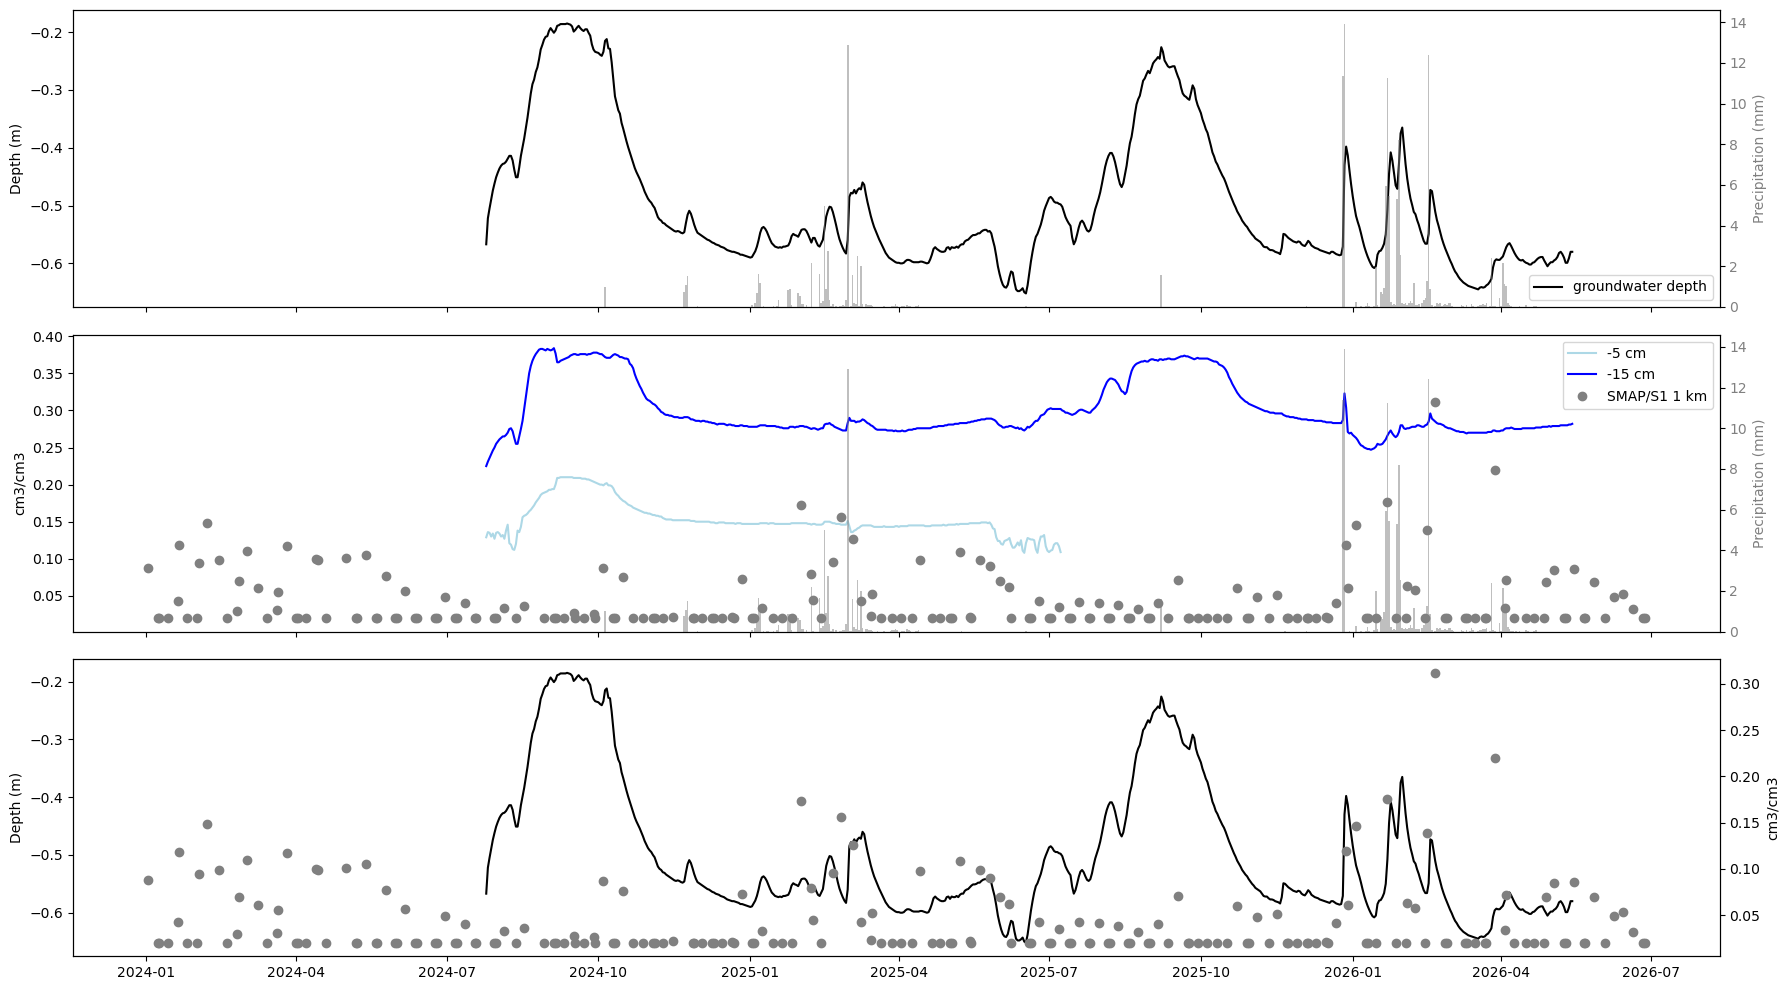

In [ ]:
# Figure
fig, (ax1, ax2, ax5) = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu.index, insitu['TEROS12-05cm_water-content_m3m3'], label='-5 cm', c='lightblue', alpha=1)
ax2.plot(insitu.index, insitu['TEROS12-15cm_water-content_m3m3'], label='-15 cm', c='blue', alpha=1)
ax2.scatter(sm_df.index, sm_df['soil_moisture'], label='SMAP/S1 1 km', c='gray', alpha=1)
ax2.set_ylabel('cm3/cm3')
ax2.legend(loc='upper right')

ax4 = ax2.twinx()
ax4.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.tick_params(axis='y', labelcolor='gray')


# Plot mas inferior
ax5.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax5.set_ylabel('Depth (m)')

ax6 = ax5.twinx()
ax6.scatter(sm_df.index, sm_df['soil_moisture'], label='SMAP/S1 1 km', c='gray', alpha=1)
ax6.set_ylabel('cm3/cm3')

plt.tight_layout()
plt.show()

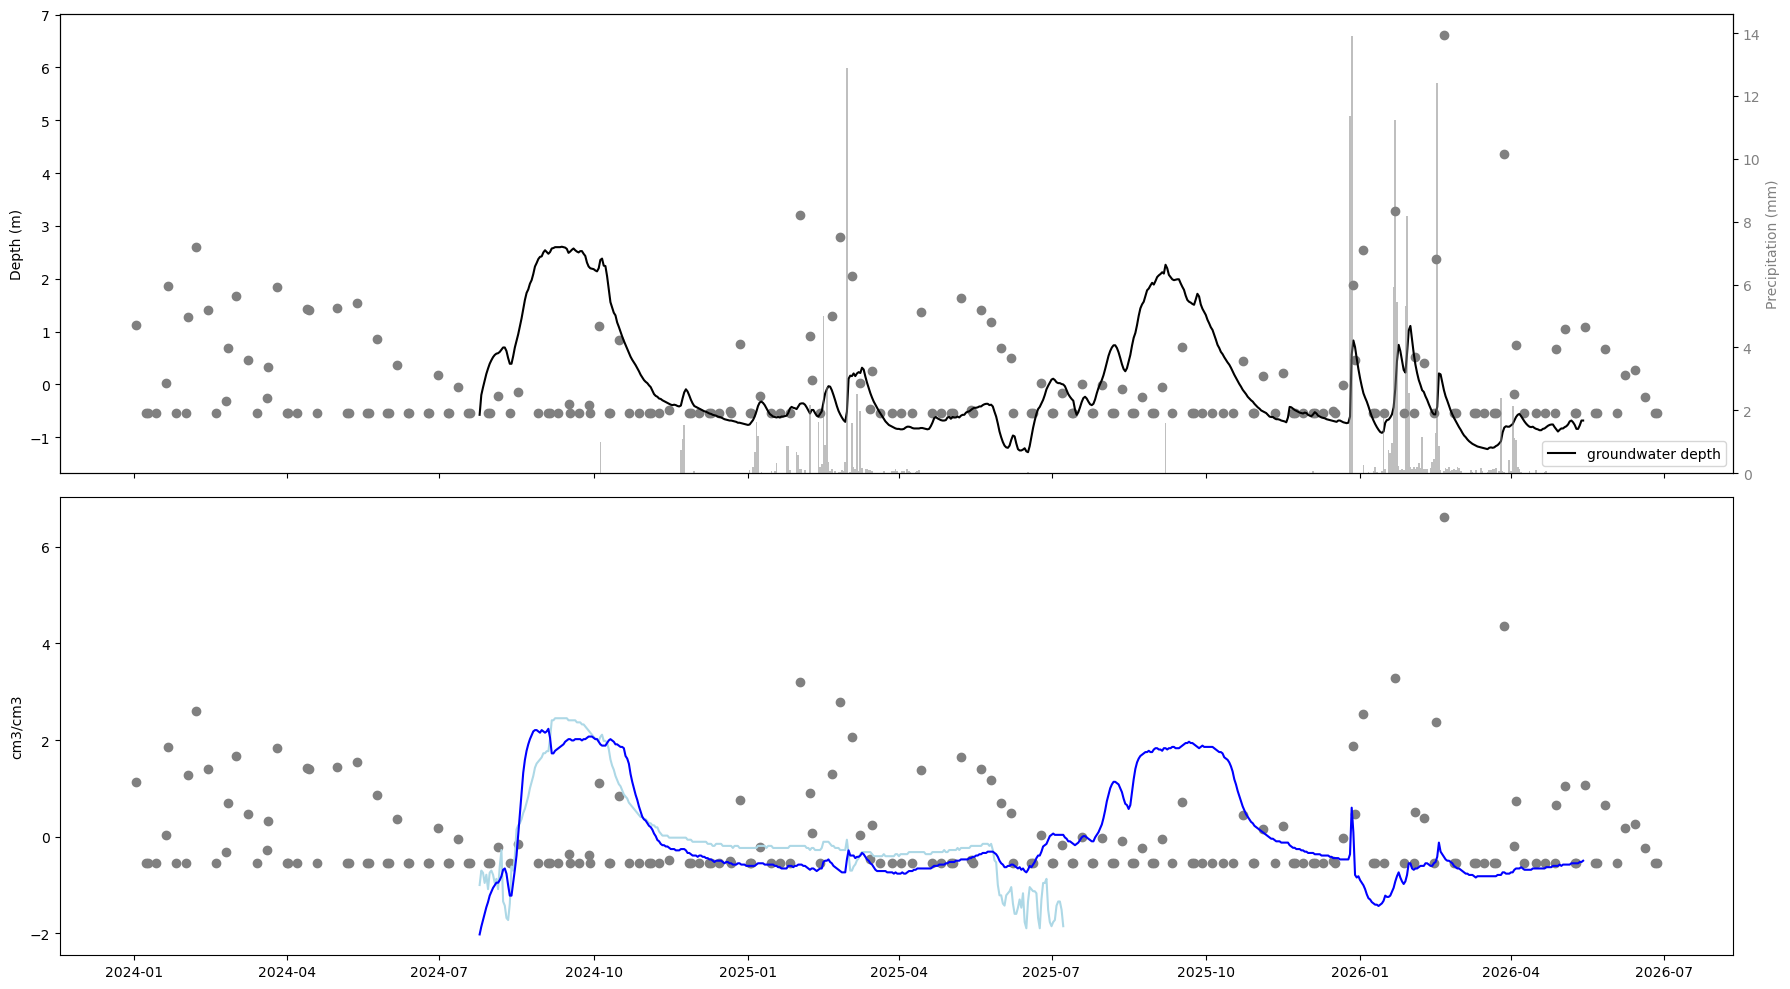

In [ ]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot superior
ax1.plot(insitu_z.index, insitu_z['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')
ax1.scatter(sm_z.index, sm_z['soil_moisture'], label='SMAP/S1 1 km', c='gray', alpha=1)

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu_z.index, insitu_z['TEROS12-05cm_water-content_m3m3'], label='-5 cm', c='lightblue', alpha=1)
ax2.plot(insitu_z.index, insitu_z['TEROS12-15cm_water-content_m3m3'], label='-15 cm', c='blue', alpha=1)
ax2.scatter(sm_z.index, sm_z['soil_moisture'], label='SMAP/S1 1 km', c='gray', alpha=1)
ax2.set_ylabel('cm3/cm3')

plt.tight_layout()
plt.show()